## 統計的にdata2vecから得られる特徴表現を調査したい！

## 準備

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import random
import numpy as np
import torch
import pandas as pd
import json
import h5py
from pathlib import Path
import copy
from omegaconf import OmegaConf
import hydra
import pretrain


os.chdir(
    "/workspaces/MLMvsData2vec/"
)  # 変更したいディレクトリのパスを指定
# 現在の作業ディレクトリを確認
print("Current working directory:", os.getcwd())

# frameworks = ["data2vec", "mlm", "rnafm", "rinalmo"]
frameworks = ["data2vec", "mlm", "data2vec_mlm", "rinalmo"]
framework_colors = {
    "data2vec": "orange",
    "mlm": "blue",
    "data2vec_mlm": "green",
    "rinalmo": "gray",
}
nucleotides = ["A", "C", "G", "U"]
family = [
    "5s",
    "16s",
    "23s",
    "grp1",
    "RNaseP",
    "srp_long",
    "srp_short",
    "telomerase",
    "tmRNA",
    "tRNA",
]

framework_path_dict = {
    "data2vec": Path(
        "./results/pretrain_results/data2vec/20260307T153057/"
    ),
    "mlm": Path("./results/pretrain_results/mlm/20260316T030756/"),
    "data2vec_mlm": Path("./results/pretrain_results/data2vec/20260324T045257/"),
    "rinalmo": Path("./data/embeddings/RiNALMo_ArchiveII.h5"),
}

archiveII_file = pd.read_csv("./data/SS_data/ArchiveII.csv")

# シード値の設定
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Current working directory: /workspaces/MLMvsData2vec


In [7]:
# 予測対象とする配列を選択

metadata = {
    "id": "",
    "data2vec_score": 0.0,
    "mlm_score": 0.0,
}

fam_representatives = {fam: {} for fam in family}

# compare_kinds = {
#     "both_high": copy.deepcopy(metadata),
#     "both_low": copy.deepcopy(metadata),
#     "d2v_than_mlm": copy.deepcopy(metadata),
#     "mlm_than_d2v": copy.deepcopy(metadata),
# }

# fam_representatives = {fam: copy.deepcopy(compare_kinds) for fam in family}

# both_high_or_low_csv = pd.read_csv(
#     "../data/bpseq_outputs/ArchiveII_famfold/both_high/best_rna_both_high.csv"
# )
# mlm_vs_d2v_csv = pd.read_csv(
#     "../data/bpseq_outputs/ArchiveII_famfold/mlm_than_d2v/best_rna_mlm_than_d2v.csv"
# )

# for fam in family:
#     fam_csv = pd.read_csv(f"../data/SS_data/archiveII_famfold/{fam}/test.csv")

#     both_df = both_high_or_low_csv[both_high_or_low_csv["seq_ids"].isin(fam_csv["id"])]
#     vs_df = mlm_vs_d2v_csv[mlm_vs_d2v_csv["seq_ids"].isin(fam_csv["id"])]

#     fam_representatives[fam]["both_high"]["id"] = both_df.iloc[0]["seq_ids"]
#     fam_representatives[fam]["both_high"]["mlm_score"] = both_df.iloc[0]["score_1"]
#     fam_representatives[fam]["both_high"]["data2vec_score"] = both_df.iloc[0]["score_2"]

#     fam_representatives[fam]["both_low"]["id"] = both_df.iloc[-1]["seq_ids"]
#     fam_representatives[fam]["both_low"]["mlm_score"] = both_df.iloc[-1]["score_1"]
#     fam_representatives[fam]["both_low"]["data2vec_score"] = both_df.iloc[-1]["score_2"]

#     fam_representatives[fam]["mlm_than_d2v"]["id"] = vs_df.iloc[0]["seq_ids"]
#     fam_representatives[fam]["mlm_than_d2v"]["mlm_score"] = vs_df.iloc[0]["score_1"]
#     fam_representatives[fam]["mlm_than_d2v"]["data2vec_score"] = vs_df.iloc[0][
#         "score_2"
#     ]

#     fam_representatives[fam]["d2v_than_mlm"]["id"] = vs_df.iloc[-1]["seq_ids"]
#     fam_representatives[fam]["d2v_than_mlm"]["mlm_score"] = vs_df.iloc[-1]["score_1"]
#     fam_representatives[fam]["d2v_than_mlm"]["data2vec_score"] = vs_df.iloc[-1][
#         "score_2"
#     ]


In [4]:
# アテンション評価関数の定義
def bp2matrix(L, base_pairs):
    matrix = np.zeros((L, L), dtype=np.float16)
    if base_pairs != []:
        # base pairs are 1-based
        bp = np.array(base_pairs) - 1
        matrix[bp[:, 0], bp[:, 1]] = 1
        matrix[bp[:, 1], bp[:, 0]] = 1

    return matrix


def assess_attention(attn, gt, n_heads=20, n_layers=12):
    """
    Assess the quality of attention maps against ground truth contact maps.
    Args:
        attn (np.Ndarray): Attention maps of shape (n_heads*n_layers, L, L).
        gt (np.Ndarray): Ground truth contact map of shape (L, L).
    Returns:
        float: the percentage of attention weights that indicate the pairing of structural tokens within each attention head of the architecture
    """

    max_score = 0.0
    for hl in range(n_heads * n_layers):
        score = np.sum(attn[hl] * gt) / np.sum(attn[hl])
        if score > max_score:
            max_score = score.astype(float)

    return max_score

In [4]:
# 表現学習モデルの準備

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

models = {f"{framework_name}": None for framework_name in frameworks}

pretrain.utils.setup_config()

for framework_name in frameworks:
    if framework_name == "rinalmo":
        continue
    
    model_path = framework_path_dict[framework_name]
    if not model_path.exists():
        raise FileNotFoundError(f"Pretrain model path {model_path} does not exist.")

    cfg_path = model_path / f"train_config/.hydra/config.yaml"
    cfg = OmegaConf.load(cfg_path)
    cfg.common.batch_size = cfg.model_size.gradient_accumulation_steps

    if framework_name == "data2vec":
        model = pretrain.models.data2vecModel(
            **cfg.framework,
            padding_idx=cfg.dataset.tokens.index("<pad>"),
            num_tokens=len(cfg.dataset.tokens),
            experiment_cfg=cfg.experiment,
            device=device
        )
    elif framework_name == "data2vec_mlm":
        model = pretrain.models.data2vecModel(
            **cfg.framework,
            padding_idx=cfg.dataset.tokens.index("<pad>"),
            num_tokens=len(cfg.dataset.tokens),
            experiment_cfg=cfg.experiment,
            device=device
        )
    else:
        model = pretrain.models.MLMModel(
            **cfg.framework,
            padding_idx=cfg.dataset.tokens.index("<pad>"),
            num_tokens=len(cfg.dataset.tokens),
            experiment_cfg=cfg.experiment,
            device=device
        )

    ## 事前学習モデルの重みの読み込み
    weight = f"weight_150000.pth"
    model._load_state_dict(torch.load(model_path / weight, map_location=device))
    
    models[framework_name] = {
        "model": model,
        "cfg": cfg,
        "dataloader": pretrain.dataset.create_dataloader(config=cfg, split="test")
    }

/tmp/ipykernel_1287863/2441982494.py:48: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model._load_state_dict(torch.load(model_path / weight, map_location=device))


In [10]:
# メドイド法で選択した代表配列を追加

from Levenshtein import distance


def select_medoid(sequences: list) -> str:
    """
    配列リストからメドイド（他全配列への距離の総和が最小の配列）を返す
    """
    n = len(sequences)
    if n == 0:
        return None
    if n == 1:
        return sequences[0]

    min_total_dist = float("inf")
    medoid_seq = None

    # 各配列について、他の全ての配列との距離の合計を計算
    for i, seq_i in enumerate(sequences):
        total_dist = 0
        for j, seq_j in enumerate(sequences[i + 1 :], start=i + 1):
            # 配列間の編集距離を加算
            total_dist += distance(str(seq_i), str(seq_j))

        # 合計距離が最小のものを更新
        if total_dist < min_total_dist:
            min_total_dist = total_dist
            medoid_seq = seq_i

    return medoid_seq


for fam in family:
    fam_csv = pd.read_csv(f"./data/SS_data/archiveII_famfold/{fam}/test.csv")
    sequences = fam_csv["sequence"].tolist()
    medoid_seq = select_medoid(sequences)

    seq_id = fam_csv[fam_csv["sequence"] == medoid_seq]["id"].values[0]

    fam_representatives[fam] = {
        "id": seq_id,
    }

## 変異関係なくA, U, G, Cの表現を比較

In [ ]:
from tqdm import tqdm

# 配列表現の抽出
family_representatives = {}
for framework_name in frameworks:
    print(f"Extracting representations for {framework_name}...")
    if framework_name == "rinalmo":
        with h5py.File(framework_path_dict[framework_name], "r") as hdf:
            # 比較対象とする配列の読み込み
            family_representatives[framework_name] = {fam: {} for fam in family}
            for fam in family:
                print(f"Extracting representation for {fam}...")
                seq_id = fam_representatives[fam]["id"]
                family_representatives[framework_name][fam] = {
                    "seq_id": seq_id,
                    "sequence": archiveII_file[archiveII_file["id"] == seq_id][
                        "sequence"
                    ].values[0],
                    "representation": torch.from_numpy(hdf[seq_id][:]).requires_grad_(
                        False
                    ),
                }
    else:
        family_representatives[framework_name] = {fam: {} for fam in family}
        
        seq_dict = {fam: {} for fam in family}
        
        for fam in family:
            seq_dict[fam]["seq_id"] = fam_representatives[fam]["id"]
            for batch in tqdm(models[framework_name]["dataloader"]):
                assert len(batch["seq_ids"]) == 1, "Batch size should be 1 for representation extraction."
                batch_seq_id = batch["seq_ids"][0]
                if batch_seq_id == seq_dict[fam]["seq_id"]:
                    seq_dict[fam]["batch"] = batch
                    break

        for fam, seq_info in seq_dict.items():
            print(f"Extracting representation for {fam}...")
            seq_id = seq_info["seq_id"]
            representation = models[framework_name]["model"]._test(seq_info["batch"])["repr"] # B x L x E
            
            family_representatives[framework_name][fam] = {
                "seq_id": seq_id,
                "sequence": archiveII_file[archiveII_file["id"] == seq_id][
                    "sequence"
                ].values[0],
                "representation": representation.squeeze(0).detach(),  # L x E
            }

Extracting representations for data2vec...


 80%|███████▉  | 3073/3864 [00:05<00:01, 524.22it/s]


Extracting representation for 5s...
Extracting representation for 16s...
Extracting representation for 23s...
Extracting representation for grp1...
Extracting representation for RNaseP...
Extracting representation for srp_long...
Extracting representation for srp_short...
Extracting representation for telomerase...
Extracting representation for tmRNA...
Extracting representation for tRNA...
Extracting representations for mlm...
Extracting representation for 5s...
Extracting representation for 16s...
Extracting representation for 23s...
Extracting representation for grp1...
Extracting representation for RNaseP...
Extracting representation for srp_long...
Extracting representation for srp_short...
Extracting representation for telomerase...
Extracting representation for tmRNA...
Extracting representation for tRNA...
Extracting representations for data2vec_mlm...
Extracting representation for 5s...
Extracting representation for 16s...
Extracting representation for 23s...
Extracting repres

Family: 5s


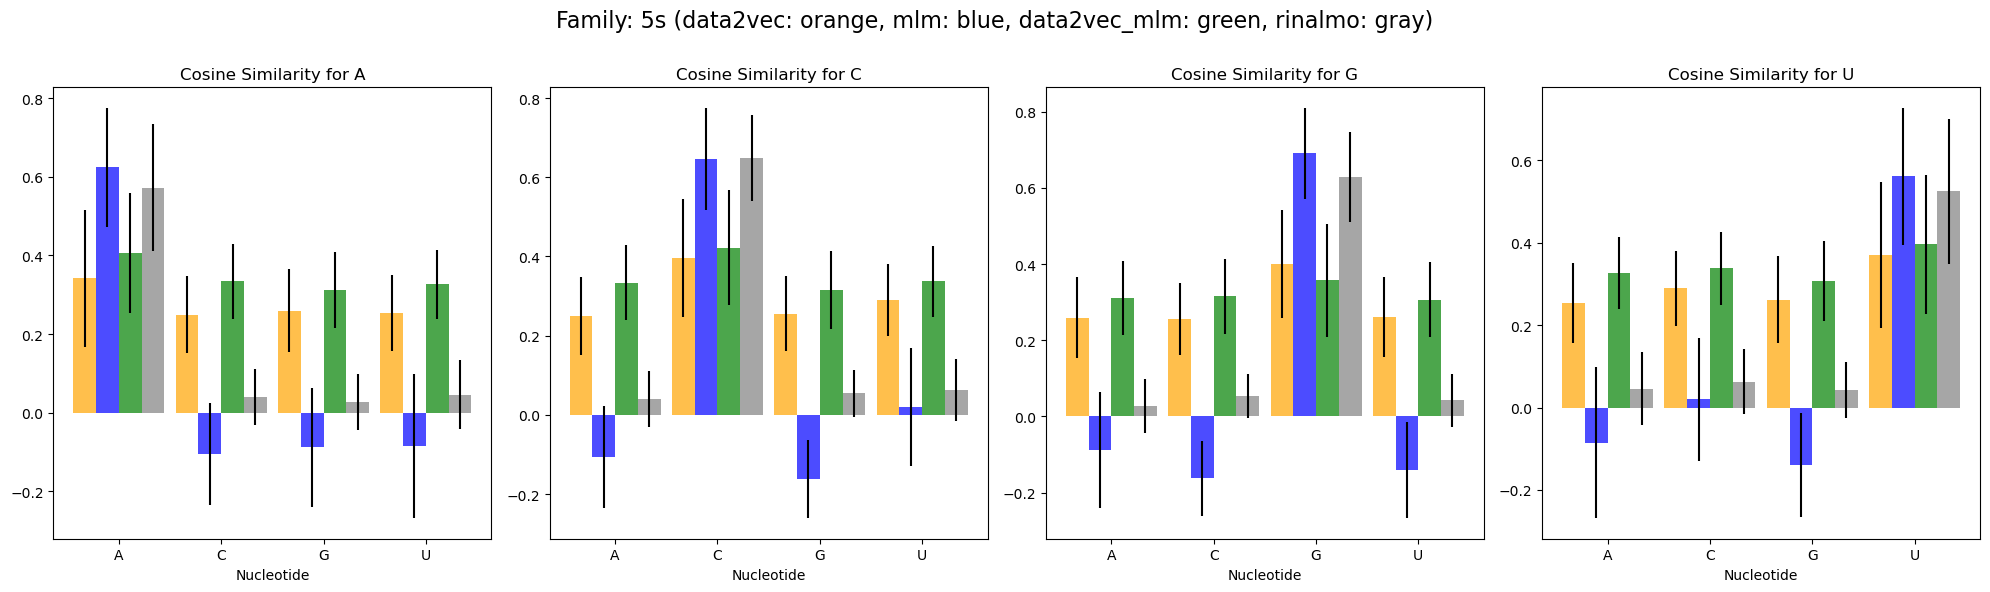

Family: 16s


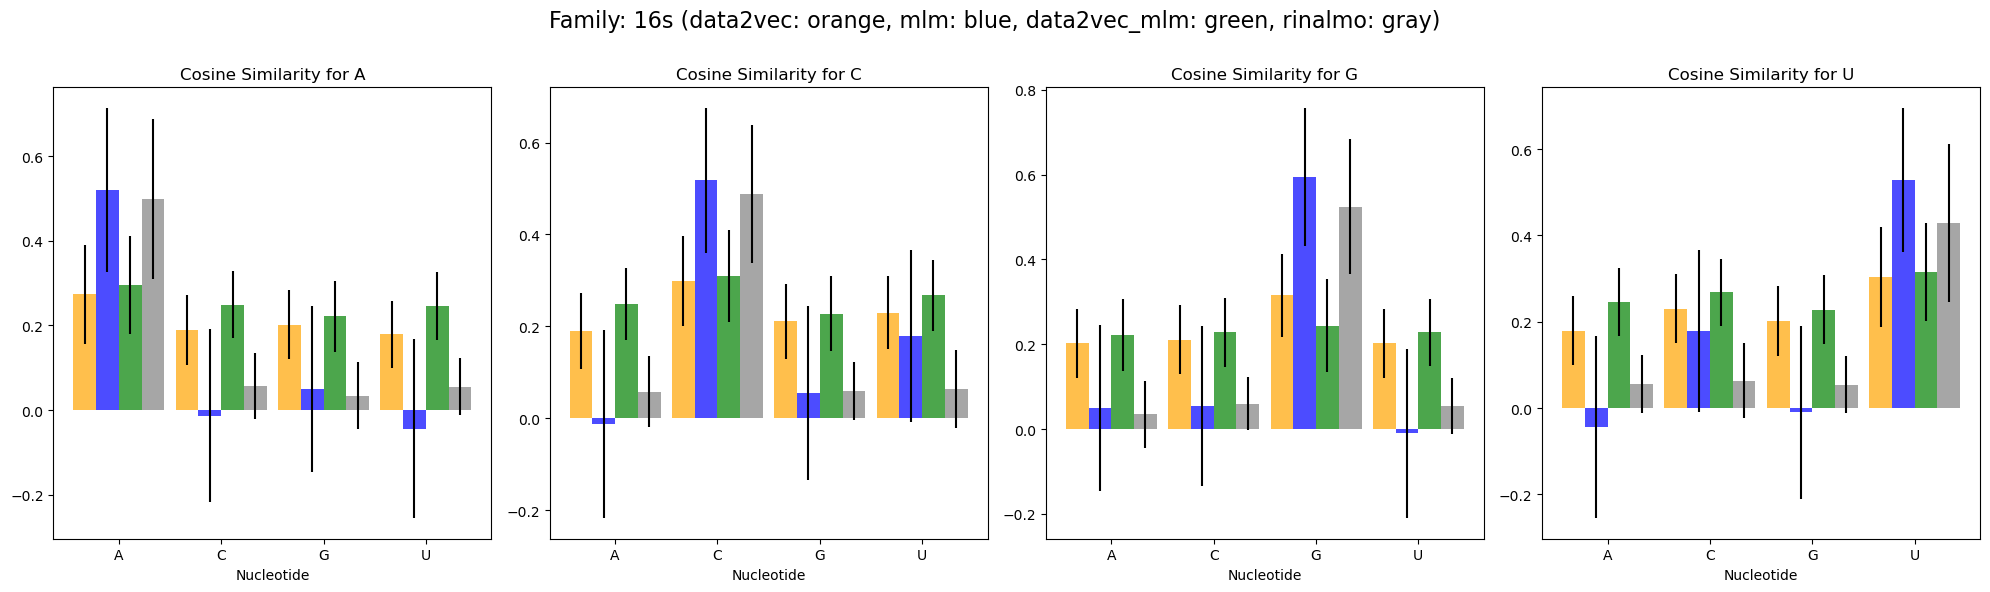

Family: 23s


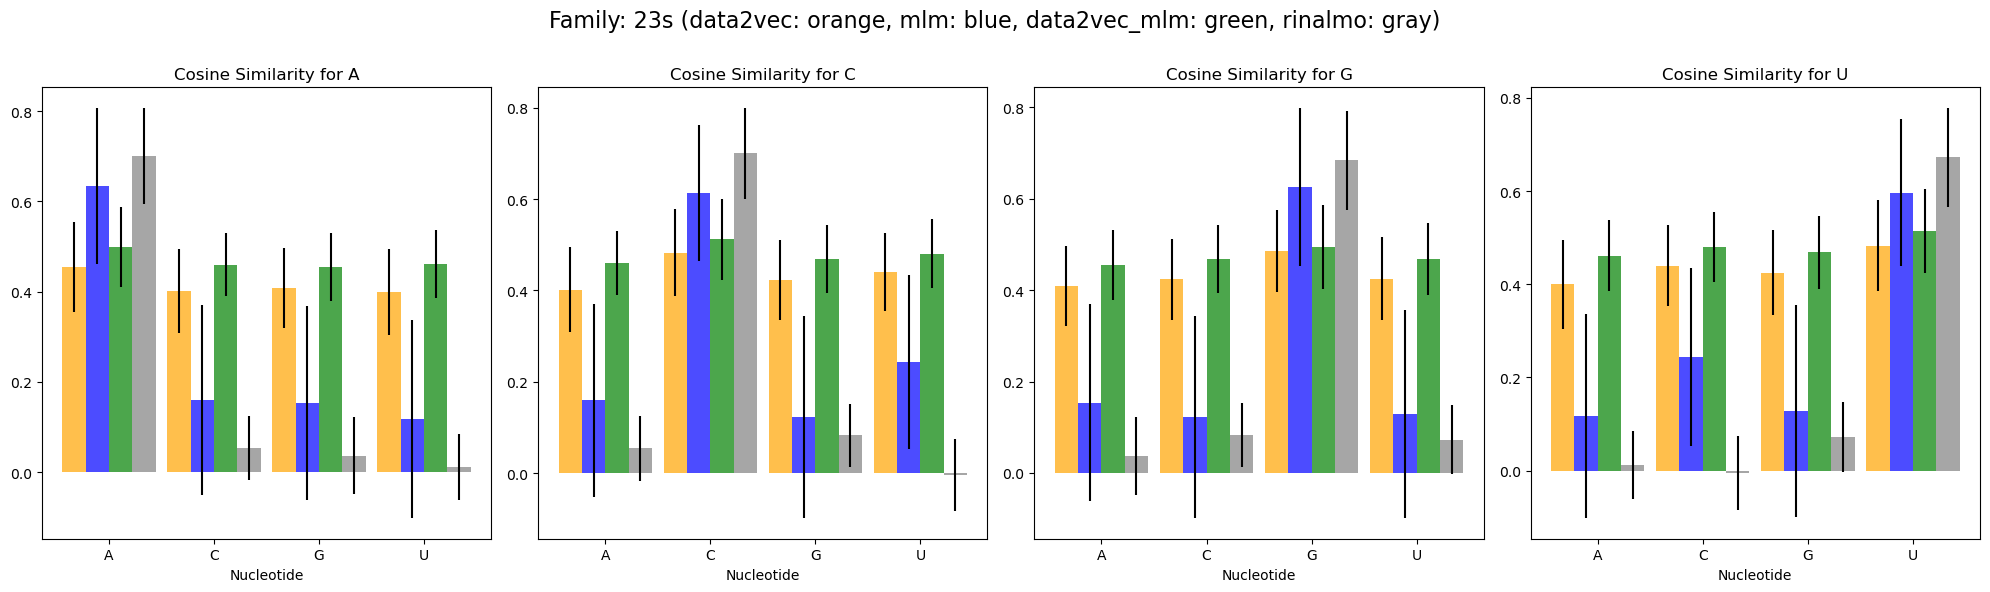

Family: grp1


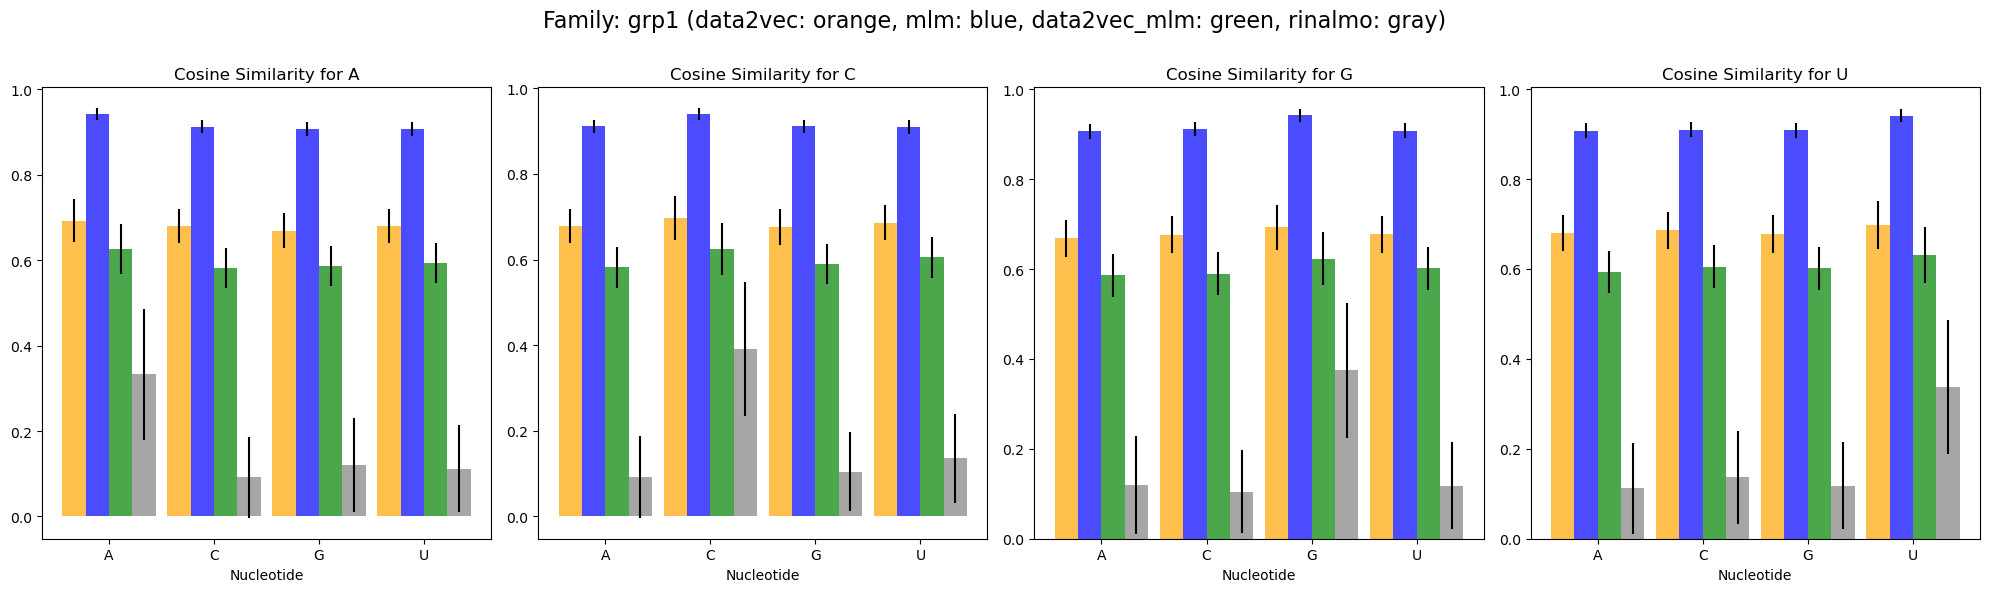

Family: RNaseP


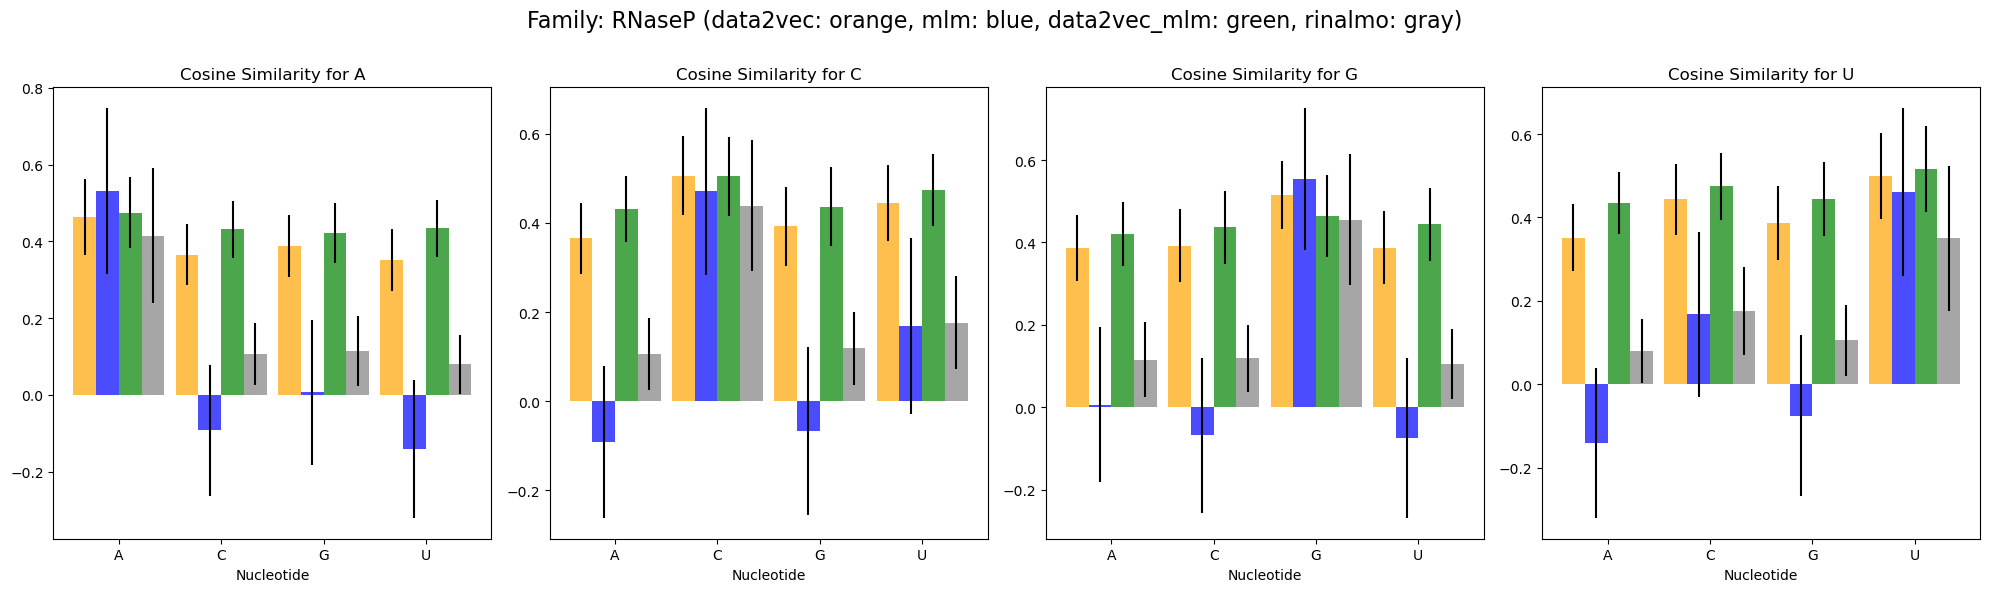

Family: srp_long


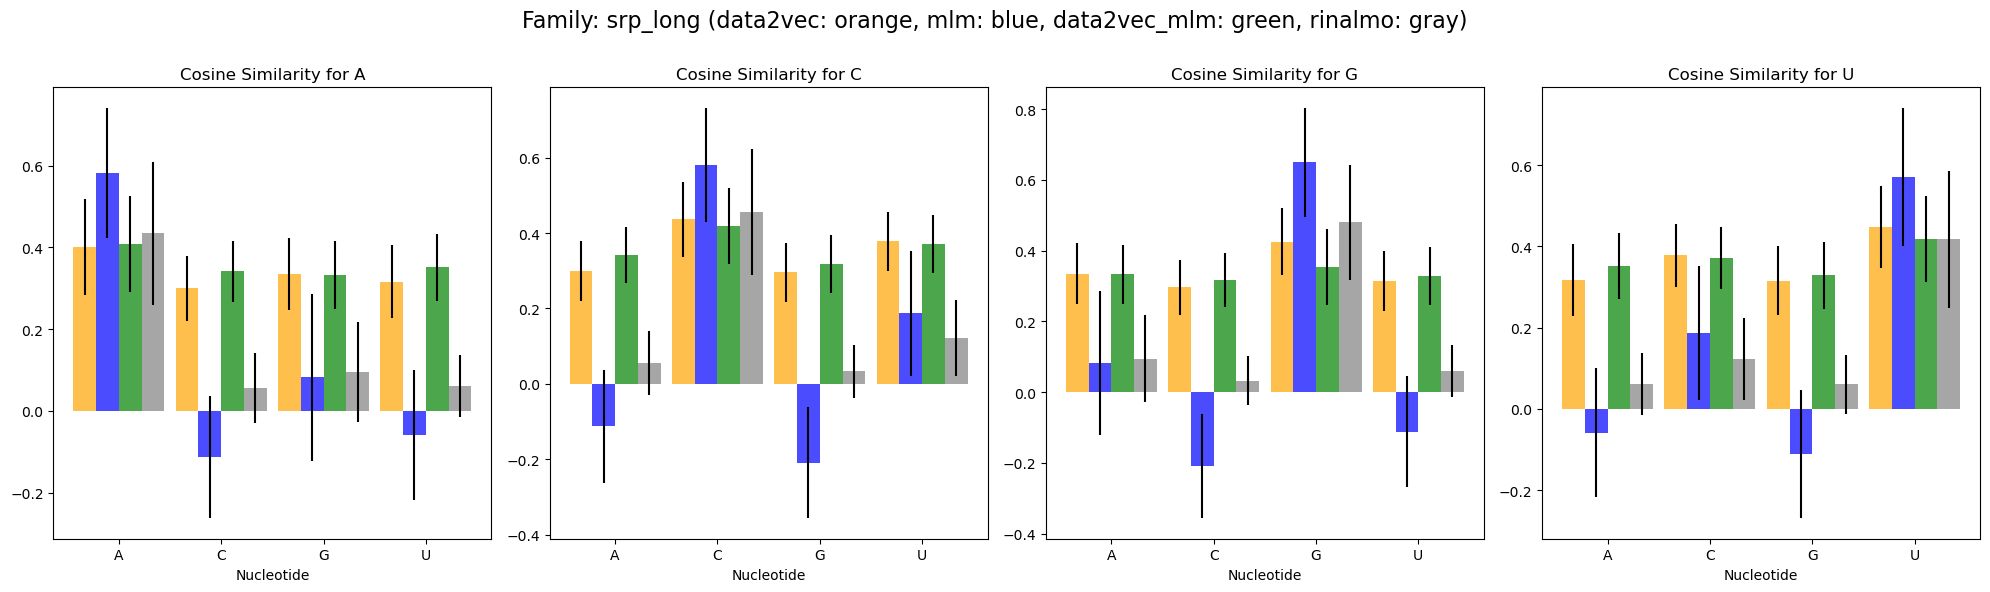

Family: srp_short


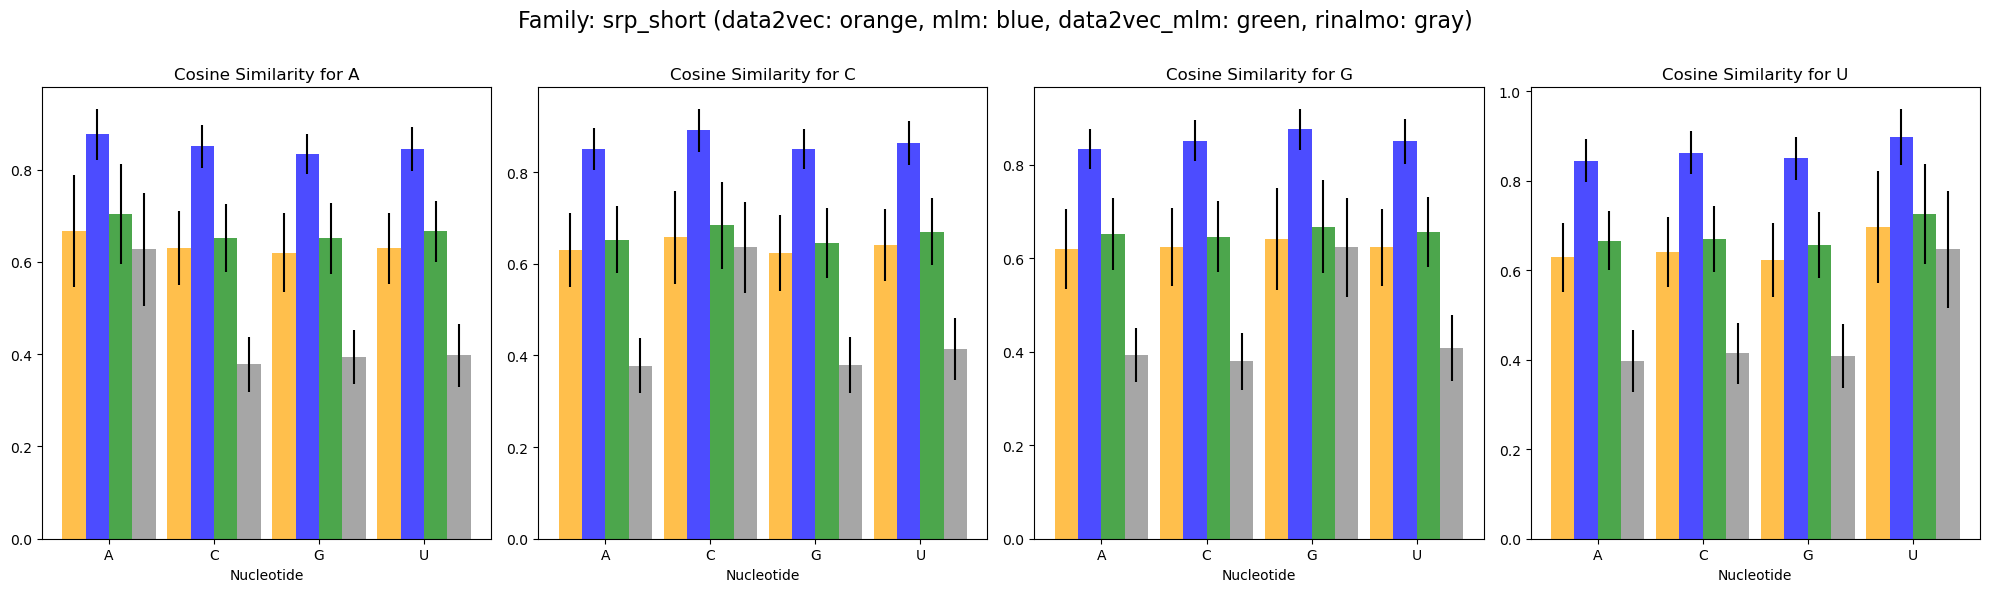

Family: telomerase


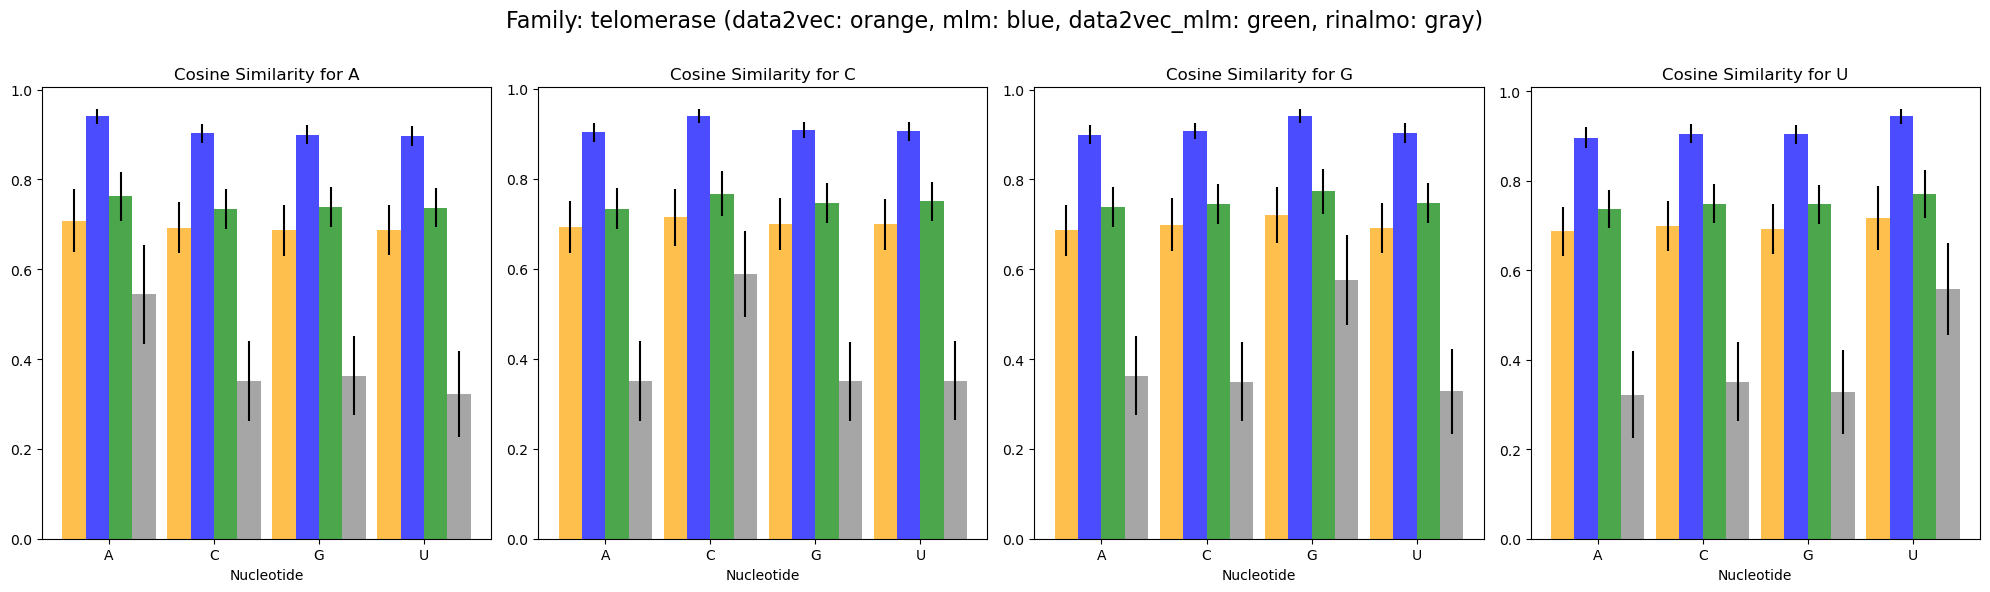

Family: tmRNA


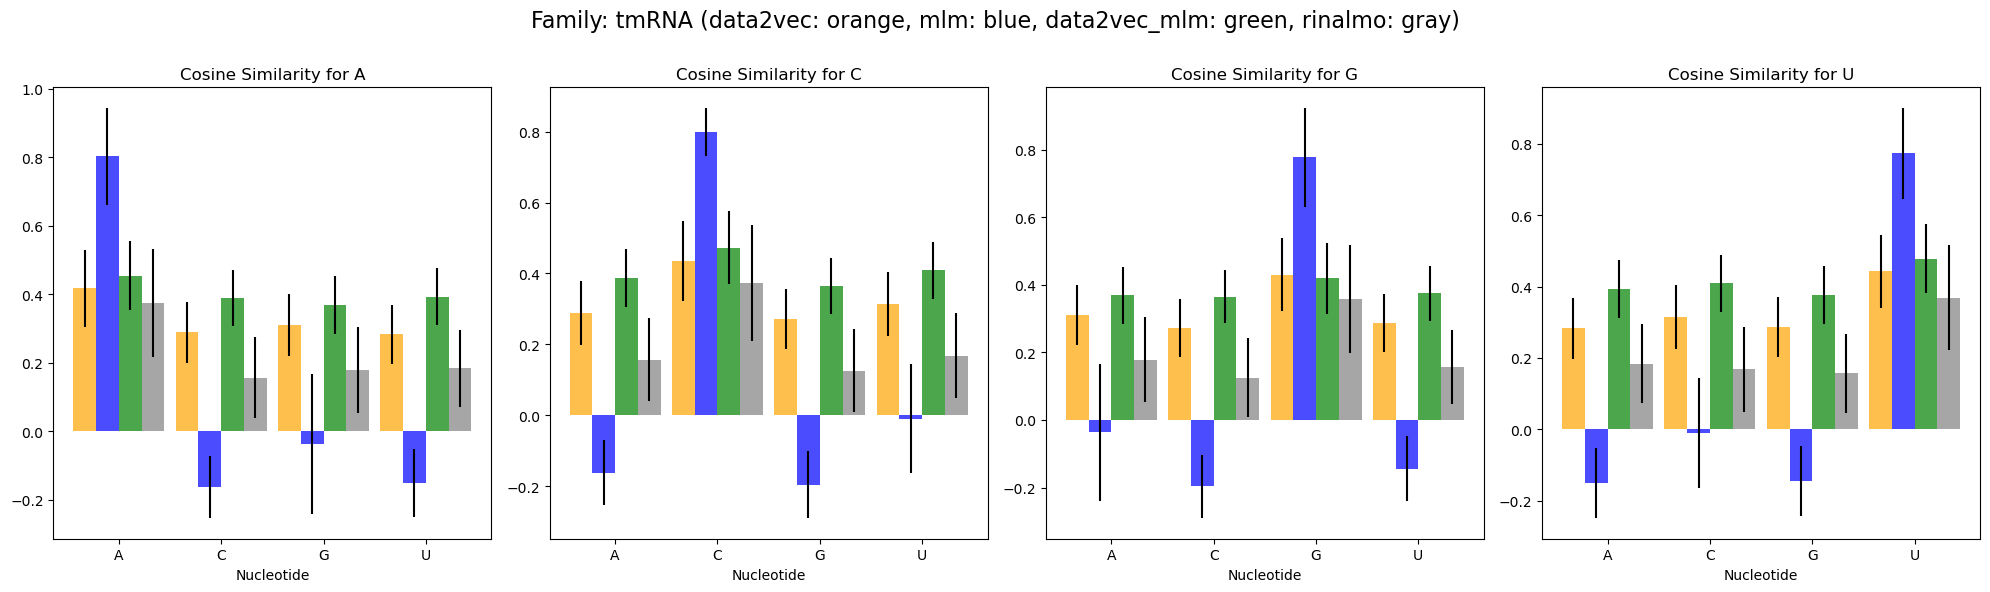

Family: tRNA


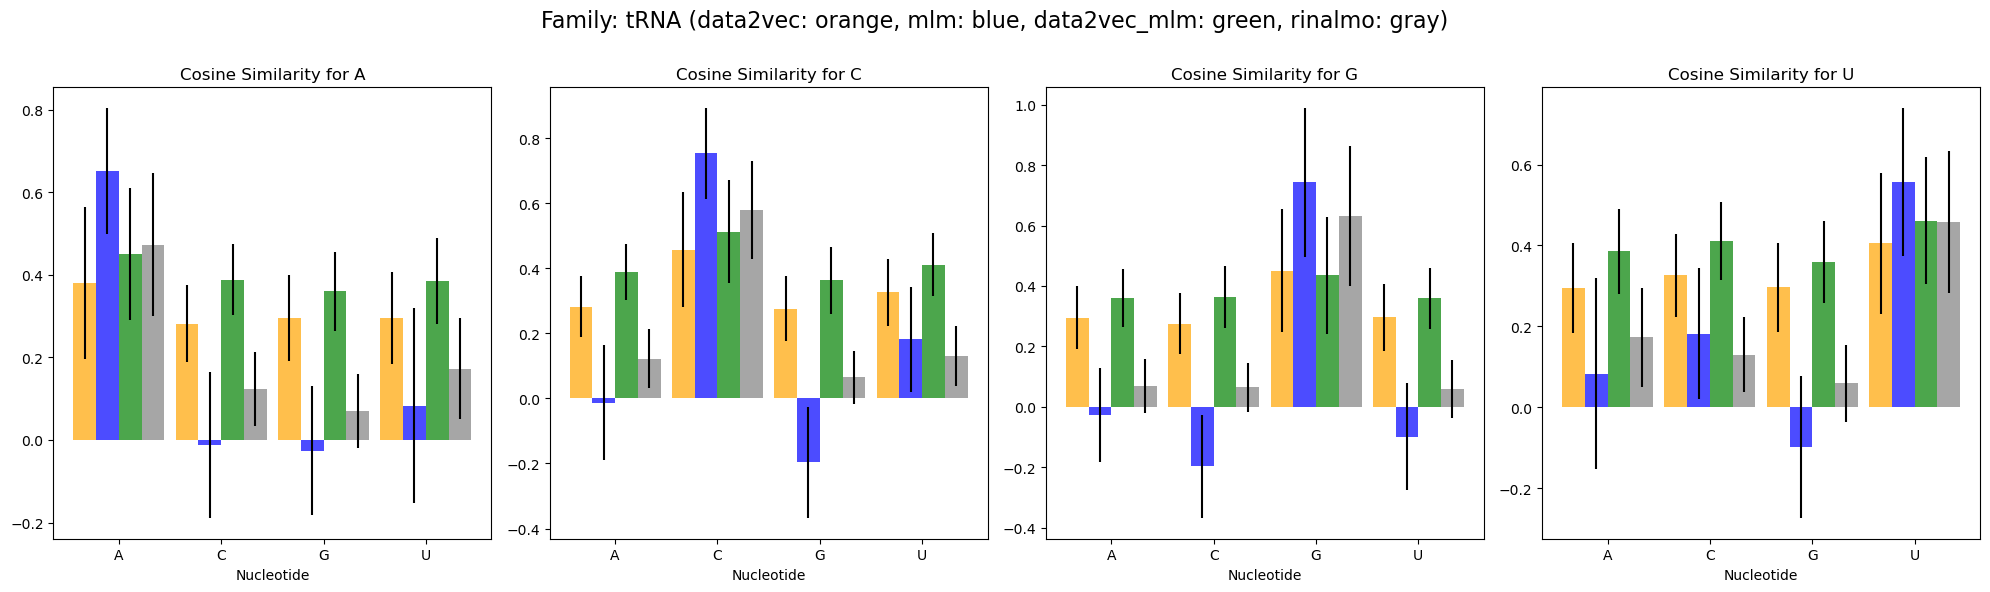

In [27]:
# ファミリーごとに選ばれた配列について，A, C, G, T のそれぞれの塩基の表現が，他の塩基とどの程度似ているかを計算する

all_results = {
    framework_name: {
        nt: {each_nt: [] for each_nt in nucleotides} for nt in nucleotides
    }
    for framework_name in frameworks
}
for fam in family:
    print(f"Family: {fam}")
    fig, axes = plt.subplots(1, 4, figsize=(20, 6))  # (compare_kinds, nucleotides)
    x = np.arange(len(nucleotides)) * (1.0 + 0.125 * (len(frameworks) - 3))
    width_base = 0.25
    width = width_base * len(frameworks)

    for framework_name in frameworks:
        rep = family_representatives[framework_name][fam][
            "representation"
        ]
        seq = family_representatives[framework_name][fam]["sequence"]

        nt_comparison = {
            nt: {each_nt: [] for each_nt in nucleotides} for nt in nucleotides
        }

        seq_token = torch.tensor(
            [nucleotides.index(nt) for nt in seq],
            dtype=torch.uint8,
            requires_grad=False,
        )

        for i, nt in enumerate(seq):
            # 現在の塩基の表現
            current_rep = rep[i]
            # 他の塩基の表現との類似度を計算 (コサイン類似度のみ)

            cosine_similarities = torch.nn.functional.cosine_similarity(
                current_rep.unsqueeze(0), rep, dim=1
            ).requires_grad_(False)

            for idx, nucleotide in enumerate(nucleotides):
                nt_comparison[nt][nucleotide].append(
                    cosine_similarities[torch.where(seq_token == idx)]
                )

        for idx, nt in enumerate(nucleotides):
            for idx2, nt2 in enumerate(nucleotides):
                nt_comparison[nt][nt2] = torch.cat(nt_comparison[nt][nt2]).detach().cpu().numpy()

                all_results[framework_name][nt][nt2].append(
                    nt_comparison[nt][nt2]
                )

                mean_cosine_similarity = np.mean(nt_comparison[nt][nt2])

                std_cosine_similarity = np.std(nt_comparison[nt][nt2])

                # コサイン類似度の結果ごとに, frameworkを棒グラフで重ねて図示
                coodinate = -width_base * (
                    (len(frameworks) - 1) / 2
                ) + width_base * frameworks.index(framework_name)

                axes[idx].bar(
                    x[idx2] + coodinate,
                    mean_cosine_similarity,
                    width=width_base,
                    yerr=std_cosine_similarity,
                    alpha=0.7,
                    color=framework_colors[framework_name],
                )

            axes[idx].set_title(f"Cosine Similarity for {nt}")
            axes[idx].set_xlabel("Nucleotide")
            # axes[idx].set_ylabel(
            #     f"d2v: {fam_representatives[fam]['data2vec_score']:.3f}, mlm: {fam_representatives[fam]['mlm_score']:.3f}"
            # )
            axes[idx].set_xticks(x)
            axes[idx].set_xticklabels(nucleotides)

    # 類似度の結果を図示
    plt.suptitle(
        f"Family: {fam} ({', '.join([f'{f}: {framework_colors[f]}' for f in frameworks])})",
        fontsize=16,
    )
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)  # タイトルとグラフの間隔を調整
    plt.show()


# 全てのファミリーの結果をまとめて図示
# fig, axes = plt.subplots(5, 4, figsize=(20, 20))  # (compare_kinds, nucleotides)
# x = np.arange(len(nucleotides)) * (1.0 + 0.125 * (len(frameworks) - 3))
# width = width_base * len(frameworks)
# for compare_idx, compare_kind in enumerate(["medoid"] + list(compare_kinds.keys())):
#     for idx, nt in enumerate(nucleotides):
#         for idx2, nt2 in enumerate(nucleotides):
#             for framework_name in frameworks:
#                 all_results[framework_name][compare_kind][nt][nt2] = np.concatenate(
#                     all_results[framework_name][compare_kind][nt][nt2]
#                 )

#                 mean_cosine_similarity = np.mean(
#                     all_results[framework_name][compare_kind][nt][nt2]
#                 )

#                 std_cosine_similarity = np.std(
#                     all_results[framework_name][compare_kind][nt][nt2]
#                 )

#                 coodinate = -width_base * (
#                     (len(frameworks) - 1) / 2
#                 ) + width_base * frameworks.index(framework_name)
#                 color = framework_colors[framework_name]

#                 axes[compare_idx, idx].bar(
#                     x[idx2] + coodinate,
#                     mean_cosine_similarity,
#                     width=width_base,
#                     yerr=std_cosine_similarity,
#                     alpha=0.7,
#                     color=color,
#                 )

#         axes[compare_idx, idx].set_title(f"Cosine Similarity for {nt}")
#         axes[compare_idx, idx].set_xlabel("Nucleotide")
#         axes[compare_idx, idx].set_ylabel(f"{compare_kind}")
#         axes[compare_idx, idx].set_xticks(x)
#         axes[compare_idx, idx].set_xticklabels(nucleotides)


# plt.suptitle(
#     f"Overall Comparison ({', '.join([f'{f}: {framework_colors[f]}' for f in frameworks])})",
#     fontsize=16,
# )
# plt.tight_layout()
# plt.subplots_adjust(top=0.95)  # タイトルとグラフの間隔を調整
# plt.show()

Framework: data2vec
  Correlation between similarity and F1 score: 0.725
  Regression line: y = 8.672x + -0.310
Framework: mlm
  Correlation between similarity and F1 score: 0.733
  Regression line: y = 0.828x + 0.109


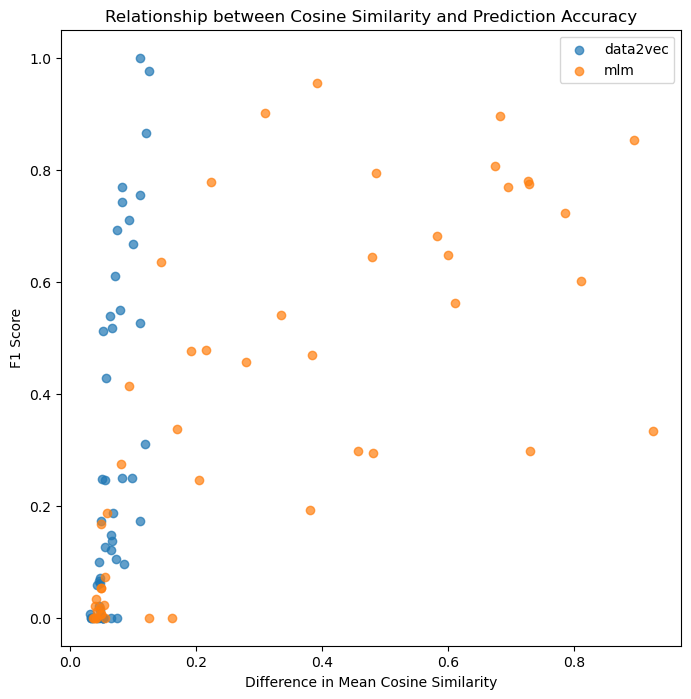

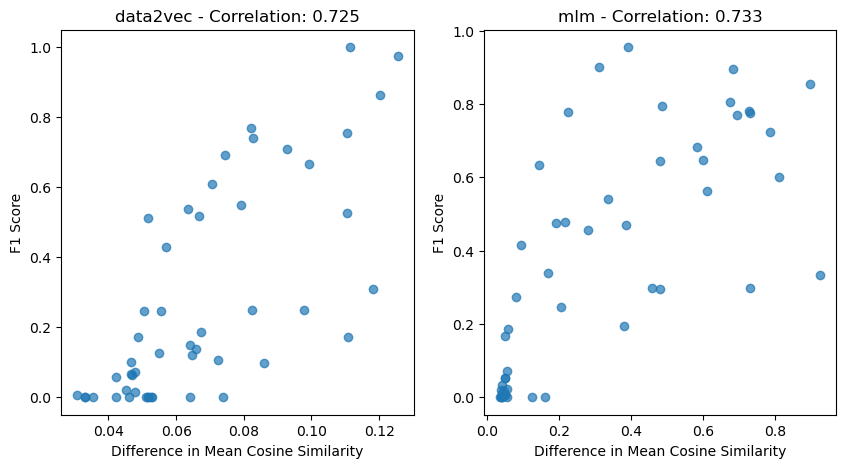

In [25]:
# 各配列について，ACGUに対応する類似度の分散と，その配列の予測精度との関係を散布図で示す
frameworks = ["data2vec", "mlm"]

fig, axes = plt.subplots(figsize=(8, 8))
fig2, axes2 = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
for framework_idx, framework_name in enumerate(frameworks):
    print(f"Framework: {framework_name}")
    output_similarity = []
    output_f1_score = []
    for fam in family:
        for compare_idx, compare_kind in enumerate(
            ["medoid"] + list(compare_kinds.keys())
        ):
            rep = family_representatives[framework_name][fam][compare_kind][
                "representation"
            ]
            seq = family_representatives[framework_name][fam][compare_kind]["sequence"]

            nt_comparison = {
                nt: {each_nt: [] for each_nt in nucleotides} for nt in nucleotides
            }

            seq_token = torch.tensor(
                [nucleotides.index(nt) for nt in seq],
                dtype=torch.uint8,
                requires_grad=False,
            )

            for i, nt in enumerate(seq):
                # 現在の塩基の表現
                current_rep = rep[i]
                # 他の塩基の表現との類似度を計算 (コサイン類似度のみ)

                cosine_similarities = torch.nn.functional.cosine_similarity(
                    current_rep.unsqueeze(0), rep, dim=1
                ).requires_grad_(False)

                for idx, nucleotide in enumerate(nucleotides):
                    nt_comparison[nt][nucleotide].append(
                        cosine_similarities[torch.where(seq_token == idx)]
                    )

            diff_mean_cosine_similarity = []
            for idx, nt in enumerate(nucleotides):
                nt_mean_cosine_similarity = 0.0
                other_mean_cosine_similarity = 0.0
                for idx2, nt2 in enumerate(nucleotides):
                    nt_comparison[nt][nt2] = torch.cat(nt_comparison[nt][nt2]).numpy()
                    if nt == nt2:
                        nt_mean_cosine_similarity += np.mean(nt_comparison[nt][nt2])
                    else:
                        other_mean_cosine_similarity += np.mean(nt_comparison[nt][nt2])

                other_mean_cosine_similarity /= len(nucleotides) - 1
                diff_mean_cosine_similarity.append(
                    nt_mean_cosine_similarity - other_mean_cosine_similarity
                )

            output_similarity.append(np.mean(np.array(diff_mean_cosine_similarity)))
            output_f1_score.append(
                fam_representatives[fam][compare_kind][f"{framework_name}_score"]
            )

    axes.scatter(
        output_similarity,
        output_f1_score,
        label=f"{framework_name}",
        alpha=0.7,
    )

    # 相関係数の計算と表示
    correlation = np.corrcoef(output_similarity, output_f1_score)[0, 1]

    # 散布図に回帰直線の計算と表示
    m, b = np.polyfit(output_similarity, output_f1_score, 1)
    # axes2[framework_idx].plot(
    #     output_similarity,
    #     m * np.array(output_similarity) + b,
    #     color="gray",
    #     label=f"Regression Line (r={correlation:.3f})",
    # )
    print(f"  Correlation between similarity and F1 score: {correlation:.3f}")
    print(f"  Regression line: y = {m:.3f}x + {b:.3f}")

    axes2[framework_idx].scatter(
        output_similarity,
        output_f1_score,
        alpha=0.7,
    )

    axes2[framework_idx].set_xlabel("Difference in Mean Cosine Similarity")
    axes2[framework_idx].set_ylabel("F1 Score")
    axes2[framework_idx].set_title(f"{framework_name} - Correlation: {correlation:.3f}")
    # axes2[framework_idx].legend()

axes.set_xlabel("Difference in Mean Cosine Similarity")
axes.set_ylabel("F1 Score")
axes.set_title("Relationship between Cosine Similarity and Prediction Accuracy")
axes.legend()


plt.show()
